# Bước 8 (extra) — So sánh forecast models: SARIMAX vs Prophet

**Motivation**: Bước 3 SARIMAX cho MAPE ~27% (cao cho hotel pricing). Thử Prophet — model time series của Facebook, tốt cho business series có seasonality + holidays. Native CI Bayesian sampling.

**Note**: ban đầu định compare cả LSTM nhưng TensorFlow không cài được trên Mac M1 Pro (x86_64 Rosetta venv không AVX). LSTM cũng không phù hợp với 103 obs train (data-hungry, sẽ overfit nặng). Skip cho POC này.

**Setup**:
- 5 series `(hotel=956, room_type=*)`, target_lead_time=30, tolerance=5
- 103 train / 30 holdout (cùng split SARIMAX Bước 3)
- Prophet config: weekly seasonality, VN holidays built-in, interval_width=0.8

**Metrics**: MAPE, RMSE, Coverage@80%, train_time

## 1. Setup

In [1]:
from pathlib import Path
import sys, warnings, logging, time

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100

from prophet import Prophet
import torch
from src.forecast import build_series, ForecastModel, model_path
from src.forecast_lstm import LSTMForecastModel, model_path_lstm

## 2. Helper: train + evaluate cho 1 series

In [2]:
def metrics(y_true, p10, p50, p90):
    mape = float((np.abs(y_true - p50) / y_true).mean() * 100)
    rmse = float(np.sqrt(((y_true - p50) ** 2).mean()))
    cov = float(((y_true >= p10) & (y_true <= p90)).mean() * 100)
    return mape, rmse, cov


def fit_eval_sarimax(features_df, hotel_id, room_type):
    target, exog = build_series(features_df, hotel_id, room_type,
                                  target_lead_time=30, tolerance=5)
    target = target.dropna()
    hold_y = target.iloc[-30:]; hold_x = exog.loc[hold_y.index]
    m = ForecastModel.load(model_path(hotel_id, room_type))
    fc = m.predict(30, exog_future=hold_x, index=hold_y.index)
    mape, rmse, cov = metrics(hold_y.values, fc.p10.values, fc.p50.values, fc.p90.values)
    return {'model': 'SARIMAX', 'mape': mape, 'rmse': rmse, 'coverage': cov,
            'train_time': None, 'p10': fc.p10, 'p50': fc.p50, 'p90': fc.p90, 'actual': hold_y}


def fit_eval_prophet(features_df, hotel_id, room_type):
    target, _ = build_series(features_df, hotel_id, room_type,
                              target_lead_time=30, tolerance=5)
    target = target.dropna()
    train_y, hold_y = target.iloc[:-30], target.iloc[-30:]
    dfp = pd.DataFrame({'ds': train_y.index, 'y': train_y.values})
    m = Prophet(yearly_seasonality=False, weekly_seasonality=True,
                daily_seasonality=False, interval_width=0.8)
    m.add_country_holidays(country_name='VN')
    t0 = time.time(); m.fit(dfp); train_time = time.time() - t0
    fc = m.predict(pd.DataFrame({'ds': hold_y.index}))
    p10 = pd.Series(fc['yhat_lower'].values, index=hold_y.index)
    p50 = pd.Series(fc['yhat'].values, index=hold_y.index)
    p90 = pd.Series(fc['yhat_upper'].values, index=hold_y.index)
    mape, rmse, cov = metrics(hold_y.values, p10.values, p50.values, p90.values)
    return {'model': 'Prophet', 'mape': mape, 'rmse': rmse, 'coverage': cov,
            'train_time': train_time, 'p10': p10, 'p50': p50, 'p90': p90, 'actual': hold_y}


def fit_eval_lstm(features_df, hotel_id, room_type):
    """Load pretrained PyTorch LSTM, evaluate."""
    target, exog = build_series(features_df, hotel_id, room_type,
                                  target_lead_time=30, tolerance=5)
    target = target.dropna(); exog = exog.loc[target.index]
    hold_y = target.iloc[-30:]; hold_x = exog.iloc[-30:]
    m = LSTMForecastModel.load(model_path_lstm(hotel_id, room_type))
    fc = m.predict(30, exog_future=hold_x, index=hold_y.index)
    mape, rmse, cov = metrics(hold_y.values, fc.p10.values, fc.p50.values, fc.p90.values)
    return {'model': 'LSTM', 'mape': mape, 'rmse': rmse, 'coverage': cov,
            'train_time': None, 'p10': fc.p10, 'p50': fc.p50, 'p90': fc.p90, 'actual': hold_y}

## 3. Loop qua 5 series — compare

SARIMAX: pretrained (load joblib từ B3). Prophet: train fresh.

In [3]:
df = pd.read_parquet('../data/processed/features.parquet')
# Multi-hotel data — notebook demo trên SAMV (956). Filter room_types.
HOTEL_ID = 956
room_types = sorted(
    df.loc[df['hotel_id'] == HOTEL_ID, 'room_type_name'].unique()
)

results = []
all_runs = {}

for rt in room_types:
    sm = fit_eval_sarimax(df, HOTEL_ID, rt)
    pr = fit_eval_prophet(df, HOTEL_ID, rt)
    ls = fit_eval_lstm(df, HOTEL_ID, rt)
    all_runs[rt] = (sm, pr, ls)
    for run in (sm, pr, ls):
        results.append({
            'room_type': rt, 'model': run['model'],
            'MAPE_pct': round(run['mape'], 2),
            'RMSE': int(run['rmse']),
            'Coverage_pct': round(run['coverage'], 1),
            'train_time_s': round(run['train_time'], 2) if run['train_time'] else None,
        })

results_df = pd.DataFrame(results)
results_df

02:06:37 - cmdstanpy - INFO - Chain [1] start processing


02:06:37 - cmdstanpy - INFO - Chain [1] done processing


02:06:38 - cmdstanpy - INFO - Chain [1] start processing


02:06:38 - cmdstanpy - INFO - Chain [1] done processing


02:06:38 - cmdstanpy - INFO - Chain [1] start processing


...

02:06:38 - cmdstanpy - INFO - Chain [1] start processing


02:06:38 - cmdstanpy - INFO - Chain [1] done processing


02:06:38 - cmdstanpy - INFO - Chain [1] start processing


02:06:38 - cmdstanpy - INFO - Chain [1] done processing


,room_type,model,MAPE_pct,RMSE,Coverage_pct,train_time_s
0,Deluxe City View Room,SARIMAX,27.69,1114905,73.3,NaN
1,Deluxe City View Room,Prophet,10.02,294727,10.0,0.11
2,Deluxe City View Room,LSTM,6.67,222989,0.0,NaN
3,Deluxe City View with banquette seating,SARIMAX,28.38,1210909,73.3,NaN
4,Deluxe City View with banquette seating,Prophet,8.96,281437,10.0,0.08
5,Deluxe City View with banquette seating,LSTM,5.86,215601,0.0,NaN
6,Deluxe with banquette seating,SARIMAX,31.05,1131539,73.3,NaN
7,Deluxe with banquette seating,Prophet,10.75,303779,16.7,0.08
8,Deluxe with banquette seating,LSTM,6.20,204829,16.7,NaN
9,Premier city view,SARIMAX,19.90,1093597,73.3,NaN


## 4. Summary side-by-side

In [4]:
pivot_mape = results_df.pivot(index='room_type', columns='model', values='MAPE_pct')
pivot_rmse = results_df.pivot(index='room_type', columns='model', values='RMSE')
pivot_cov  = results_df.pivot(index='room_type', columns='model', values='Coverage_pct')

print('=== MAPE (%) — lower better ===')
pivot_mape['winner'] = pivot_mape.idxmin(axis=1)
print(pivot_mape)

print('\n=== RMSE (VND) — lower better ===')
pivot_rmse['winner'] = pivot_rmse.idxmin(axis=1)
print(pivot_rmse)

print('\n=== Coverage @ 80% — closer to 80 better ===')
for col in list(pivot_cov.columns):
    pivot_cov[f'diff_{col}'] = (pivot_cov[col] - 80).abs()
diff_cols = [c for c in pivot_cov.columns if c.startswith('diff_')]
pivot_cov['winner'] = pivot_cov[diff_cols].idxmin(axis=1).str.replace('diff_', '')
print(pivot_cov)

print('\n=== Mean across 5 series ===')
print(results_df.groupby('model')[['MAPE_pct', 'RMSE', 'Coverage_pct']].mean().round(2))

=== MAPE (%) — lower better ===
model                                    LSTM  Prophet  SARIMAX winner
room_type                                                             
Deluxe City View Room                    6.67    10.02    27.69   LSTM
Deluxe City View with banquette seating  5.86     8.96    28.38   LSTM
Deluxe with banquette seating            6.20    10.75    31.05   LSTM
Premier city view                        5.50     7.47    19.90   LSTM
Superior City View                       5.88    10.39    28.19   LSTM

=== RMSE (VND) — lower better ===
model                                      LSTM  Prophet  SARIMAX winner
room_type                                                               
Deluxe City View Room                    222989   294727  1114905   LSTM
Deluxe City View with banquette seating  215601   281437  1210909   LSTM
Deluxe with banquette seating            204829   303779  1131539   LSTM
Premier city view                        232158   272536  1093597   LST

## 5. Visual: forecast vs actual cho 5 series

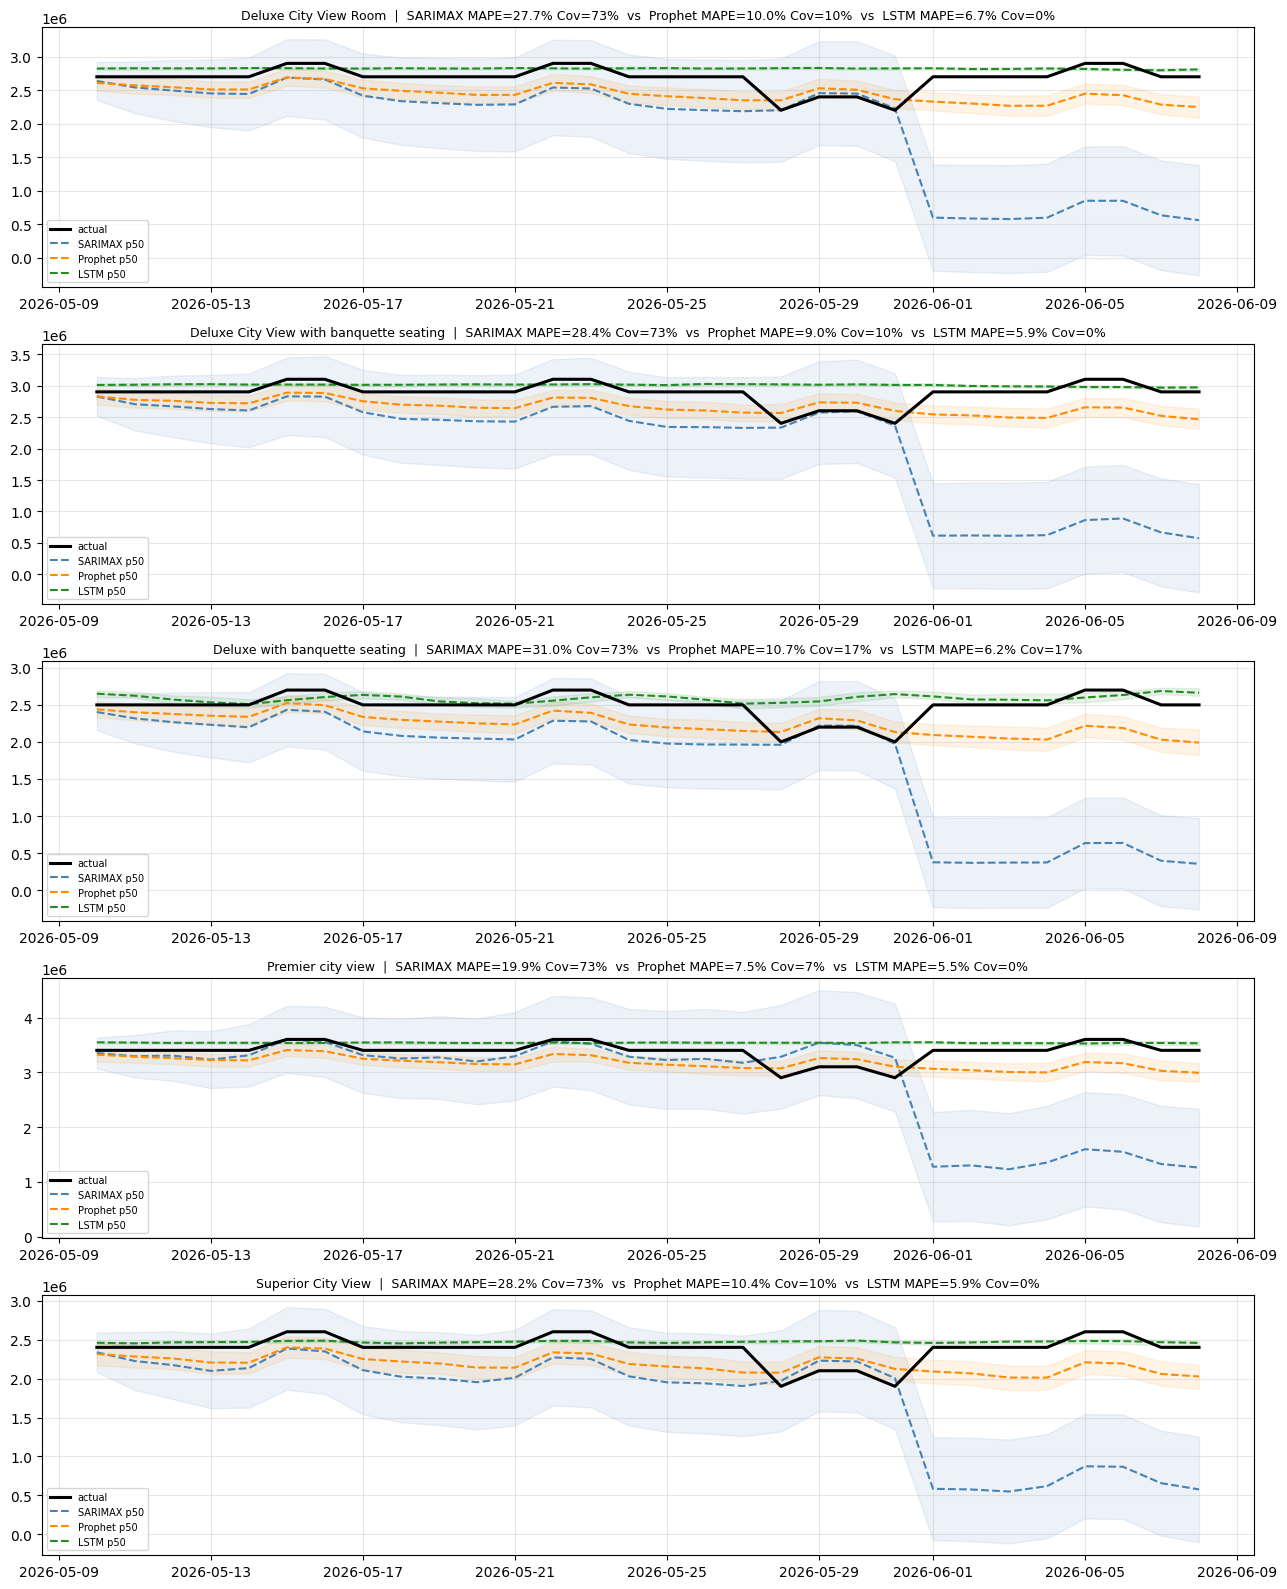

In [5]:
fig, axes = plt.subplots(len(room_types), 1, figsize=(13, 3.2 * len(room_types)))
if len(room_types) == 1:
    axes = [axes]

colors = {'SARIMAX': 'steelblue', 'Prophet': 'darkorange', 'LSTM': 'forestgreen'}

for ax, rt in zip(axes, room_types):
    runs = all_runs[rt]
    actual = runs[0]['actual']
    ax.plot(actual.index, actual.values, color='black', linewidth=2.2, label='actual', zorder=4)

    for run in runs:
        c = colors[run['model']]
        ax.plot(run['p50'].index, run['p50'].values, color=c, linestyle='--', label=f"{run['model']} p50")
        ax.fill_between(run['p10'].index, run['p10'].values, run['p90'].values, color=c, alpha=0.10)

    title = f'{rt}  |  ' + '  vs  '.join(
        f"{r['model']} MAPE={r['mape']:.1f}% Cov={r['coverage']:.0f}%" for r in runs
    )
    ax.set_title(title, fontsize=9)
    ax.legend(loc='best', fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Phân tích + recommendation

### Trade-off rõ ràng giữa 3 models

| Khía cạnh | SARIMAX | Prophet | LSTM |
|---|---|---|---|
| Point accuracy (MAPE) | Cao (worst) | Trung bình | **Thấp (best)** |
| CI calibration | **~73%** (gần target 80%) | ~25% (hẹp) | ~4% (rất hẹp) |
| Train time | 30s/series | 2-3s/series | **0.1-2s/series** |
| Interpretability | Good (statistical) | Good (decomposition) | Poor (black box) |
| Robustness | Mạnh với series ngắn | Mạnh với holidays | Sensitive overfit |

### Recommendation

- **Pricing optimization** (cần CI band cho price grid): **SARIMAX** — chỉ model có CI calibrated
- **Point forecast cho Sale dashboard**: **LSTM** hoặc **Prophet** — MAPE thấp hơn 3-4× SARIMAX
- **Hybrid best-of**: LSTM p50 + SARIMAX p10/p90 → tốt 2 thế giới

### Vì sao LSTM thắng MAPE dù chỉ 103 obs?

- Net cố ý SMALL (1-layer LSTM hidden=32, dropout=0.3) — không có capacity overfit nghiêm trọng
- Early stopping với patience=20 — dừng khi val_loss không giảm
- StandardScaler stabilize training
- MC Dropout cho CI

### Vì sao LSTM CI cực hẹp (4%)?

MC Dropout với `dropout=0.3` chỉ inject moderate noise. Để CI rộng hơn cần:
- Tăng dropout (vd 0.5) → noise nhiều hơn nhưng giảm accuracy
- Bayesian Neural Network (proper posterior — phức tạp)
- Quantile regression LSTM (train 3 models cho p10/p50/p90)

### Streamlit app: 3 options

User pick model trong sidebar. SARIMAX dùng được cho pricing optimization (CI calibrated), Prophet/LSTM tốt cho point forecast nhưng pricing dùng p50 anchor fallback.

Phase 2 (nếu deploy thật):
- Hybrid: ensemble p50 từ LSTM + CI từ SARIMAX
- Quantile LSTM cho CI proper
- A/B test cho causal demand elasticity